# 04 - Modelling

This focuses on developing and evaluating predictive models to estimate the likelihood of loan default. Multiple machine learning algorithms are trained and compared using a consistent evaluation framework. 

Given the business objective of minimizing missed defaults, particular emphasis is placed on recall while also considering precision, F1-score, and ROC-AUC. The modelling process includes baseline model development, hyperparameter tuning, threshold optimization, and performance comparison to identify the most effective model for credit risk prediction.

### Import and load

In [71]:
import pandas as pd
import numpy as np
import joblib
import time
import optuna
import warnings
import matplotlib.pyplot as plt
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.stats import ks_2samp
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation


X_train = pd.read_parquet('../data/processed/X_train.parquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet').squeeze()
X_val   = pd.read_parquet('../data/processed/X_val.parquet')
y_val   = pd.read_parquet('../data/processed/y_val.parquet').squeeze()

print(f'Train: {len(X_train):,} rows | Val: {len(X_val):,} rows')

Train: 61,442 rows | Val: 21,786 rows


In [2]:
# Summary stat of X-train
print(X_train.describe().T[['mean', 'min', 'max']])

                           mean          min          max
loan_to_income         0.217900     0.005000      3.80000
dti                   18.002290     0.000000     38.33000
fico_orig            696.967302   627.000000    847.50000
revol_util            54.871402     0.000000    193.00000
employment_years       5.708392     0.000000     10.00000
short_tenure_flag      0.131457     0.000000      1.00000
vintage_year        2013.985596  2007.000000   2015.00000
vintage_quarter        2.694948     1.000000      4.00000
open_acc_band          1.630302     0.000000      3.00000
delinq_flag            0.192311     0.000000      1.00000
pub_rec_flag           0.155545     0.000000      1.00000
purpose_risk_tier      0.730754     0.000000      2.00000
loan_amnt          14363.257218  1000.000000  35000.00000
log_annual_inc        11.062272     8.006701     12.42922
home_ownership         4.080027     0.000000      5.00000


In [3]:
# Class Imbalance Weight Calculation
# To account for class imbalance during model training, the `scale_pos_weight` parameter 
# was calculated as the ratio of non-default loans to default loans in the training dataset.

scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

scale_pos_weight: 4.43


A `scale_pos_weight` of **4.43** implies that, on average, there is approximately **1 defaulted loan for every 5 loans in the training data**, with the remaining 4 loans being non-defaults. This closely aligns with the class distribution observed during the EDA phase, indicating that the train-test split successfully preserved the underlying structure of the dataset. Applying this weight helps the model pay greater attention to the less frequent default cases, reducing the risk of overlooking potentially high-risk borrowers and supporting the project's objective of maximizing default detection.

## Model 1 — Logistic Regression

Because the training data contains approximately **1 defaulted loan for every 5 non-default loans**, `class_weight='balanced'` is used to prevent Logistic Regression from being biased toward the more common non-default class. This helps the model pay greater attention to default cases and improves its ability to identify high-risk borrowers without altering the underlying data.

Logistic Regression was trained on standardized features because its optimization process is sensitive to differences in feature scale. In contrast, XGBoost was trained on the original feature values because tree-based algorithms make decisions using feature thresholds rather than feature magnitudes, making them inherently insensitive to scaling.

In [4]:
# Scale features since Logistic Regression is sensitive to feature magnitude
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_val_lr   = scaler.transform(X_val)

# Train Logistic Regression with class balancing to address the ~1:5 default/non-default distribution
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_lr, y_train)

# Evaluate discriminatory power using ROC-AUC
lr_auc = roc_auc_score(y_val, lr_model.predict_proba(X_val_lr)[:,1])
print(f'Logistic Regression Val AUC: {lr_auc:.4f}')

Logistic Regression Val AUC: 0.6616


**Findings:**

The Logistic Regression model achieved a validation ROC-AUC of **0.6616**. This means that when comparing a randomly selected defaulted loan and a randomly selected non-defaulted loan, the model has approximately **66.2% probability of assigning a higher risk score to the defaulted loan**.

An ROC-AUC of 0.6616 indicates that the model performs better than random guessing (0.50) and captures meaningful patterns associated with default risk, although its discriminatory power remains modest. As a baseline model, this result provides a useful benchmark against which more advanced models can be evaluated.

## Model 2 — XGBoost Objective Function with time-boxed 

#### Why XGBoost with Time-Boxed Optuna?

Rather than training XGBoost using manually selected hyperparameters, Optuna was used to automatically search for the combination of hyperparameters that maximized validation ROC-AUC. This data-driven approach reduces reliance on trial-and-error parameter selection and increases the likelihood of identifying a higher-performing model.

A time-boxed optimization strategy was chosen instead of a fixed number of trials, allowing Optuna to explore as many parameter combinations as possible within a predefined computational budget. This approach provides a practical balance between model performance and runtime efficiency while ensuring that tuning remains reproducible and scalable across different computing environments.

In [6]:
# Define Optuna objective function for tuning XGBoost hyperparameters
def xgb_objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1, 10, log=True),
        # High ceiling; early stopping determines the effective number of trees
        'n_estimators':          2000,
        'early_stopping_rounds': 50,
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'scale_pos_weight': scale_pos_weight,
        'random_state':     42,
        'verbosity':        0,
        'n_jobs':           -1,
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

# Run Optuna with a seeded sampler (reproducible) and a 30-minute budget
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_xgb.optimize(xgb_objective, timeout=1800)

print(f'Best validation AUC (optimistic — tuning signal only): {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

# Train final model using Optuna-selected hyperparameters
# Refit champion with early stopping retained (sets the correct tree count)
final_xgb = XGBClassifier(
    **study_xgb.best_params,
    n_estimators=2000,
    early_stopping_rounds=50,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)
final_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)


# Evaluate the final tuned model
# X_test is reserved and evaluated only once — on the final champion model to give an unbiased production estimate.
xgb_val_auc = roc_auc_score(y_val, final_xgb.predict_proba(X_val)[:, 1])
print(f'\nEffective trees (best_iteration_): {final_xgb.best_iteration}')
print(f'XGBoost Val AUC: {xgb_val_auc:.4f}')

Best validation AUC (optimistic — tuning signal only): 0.6684
Best params: {'max_depth': 4, 'learning_rate': 0.04012544997197118, 'subsample': 0.7888208463663866, 'colsample_bytree': 0.6360958754999484, 'min_child_weight': 9, 'reg_lambda': 1.4759377326016117}

Effective trees (best_iteration_): 230
XGBoost Val AUC: 0.6684


## Model 3 — LightGBM with time-boxed Optuna

#### Why LightGBM?

LightGBM was selected as an additional gradient boosting algorithm to benchmark against XGBoost and other baseline models. Its leaf-wise tree growth strategy and computational efficiency enable it to capture complex non-linear relationships in borrower characteristics while often requiring less training time than traditional boosting approaches.

Hyperparameter optimization was performed to identify the LightGBM configuration that achieved the strongest validation ROC-AUC, ensuring that model performance was driven by empirical evidence rather than default parameter settings.

In [7]:
# Optuna objective for tuning LightGBM
def lgbm_objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'max_depth':         -1,
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':    1,
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'n_estimators':      2000,
        'objective':         'binary',
        'metric':            'auc',
        'scale_pos_weight':  scale_pos_weight,
        'random_state':      42,
        'verbosity':         -1,
        'n_jobs':            -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

# Run Optuna — seeded, quiet, 30-minute budget
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lgbm = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(lgbm_objective, timeout=1800)
print(f'Best validation AUC (tuning signal only): {study_lgbm.best_value:.4f}')
print(f'Best params: {study_lgbm.best_params}')

# Refit champion — keep early stopping, re-include fixed params
final_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    n_estimators=2000,
    max_depth=-1,
    subsample_freq=1,
    objective='binary',
    metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)
final_lgbm.fit(X_train, y_train,
               eval_set=[(X_val, y_val)],
               callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])

# Validation AUC — model-selection metric; X_test held for NB10
lgbm_val_auc = roc_auc_score(y_val, final_lgbm.predict_proba(X_val)[:, 1])
print(f'\nEffective trees (best_iteration_): {final_lgbm.best_iteration_}')
print(f'LightGBM Val AUC: {lgbm_val_auc:.4f}')

Best validation AUC (tuning signal only): 0.6684
Best params: {'num_leaves': 15, 'min_child_samples': 176, 'learning_rate': 0.012064979017159356, 'subsample': 0.5931657413392223, 'colsample_bytree': 0.7269197059144876, 'reg_lambda': 0.1692859030806679}

Effective trees (best_iteration_): 591
LightGBM Val AUC: 0.6684


In [40]:
# Save the trained Logistic Regression model and scaler for reuse during evaluation, explainability, and deployment

joblib.dump(lr_model, '../models/logistic_model.pkl')
joblib.dump(scaler,   '../models/lr_scaler.pkl')

print('Saved: models/logistic_model.pkl + models/lr_scaler.pkl')

# Save the trained XGBoost model and LightGBM model for reuse during evaluation, explainability, and deployment
joblib.dump(final_xgb, '../models/xgboost_model.pkl')
joblib.dump(final_lgbm,   '../models/lightgbm_model.pkl')

print('Saved: models/xgboost_model.pkl + models/lgbm.pkl')

Saved: models/logistic_model.pkl + models/lr_scaler.pkl
Saved: models/xgboost_model.pkl + models/lgbm.pkl


## Evaluation of all 3 models on validation set

#### Validation, Champion Selection, Stability Assessment & Production Retrain

This phase evaluates the candidate models using a comprehensive set of credit-risk performance and stability metrics, including ROC-AUC (AUC), KS Statistic (KS), Gini Coefficient (Gini), and Population Stability Index (PSI). The objective is to identify the champion model based on predictive performance, discrimination power, calibration, and robustness.

Following model comparison and champion selection, the chosen model is retrained on the full 500,000-loan production dataset to maximize the use of available information before deployment. Additional temporal stability analysis is performed across loan vintages to assess whether model performance remains consistent over time and to identify potential drift in borrower behavior or portfolio characteristics.

The outputs from this stage represent the final model performance and stability results that are reported in the project report, executive summary, and professional portfolio.

In [39]:
# Evaluate all 4 metrics of auc, ks, gini and brier on the models
models = {'Logistic': lr_model, 'XGBoost': final_xgb, 'LightGBM': final_lgbm}

val_auc = {}
rows = []
for name, m in models.items():
    X = scaler.transform(X_val) if name == 'Logistic' else X_val
    p = m.predict_proba(X)[:, 1]
    auc = roc_auc_score(y_val, p)
    fpr_, tpr_, _ = roc_curve(y_val, p)
    val_auc[name] = auc
    rows.append({'model': name,
                 'AUC':   round(auc, 4),
                 'KS':    round((tpr_ - fpr_).max(), 4),
                 'Gini':  round(2 * auc - 1, 4),
                 'Brier': round(brier_score_loss(y_val, p), 4)})

leaderboard = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
print('=== Validation metrics ===')
print()
print(leaderboard.to_string(index=False))

# Brier sanity check: a constant base-rate prediction would score p*(1-p)
base = y_val.mean()

print(f'\nBase-rate Brier reference: {base*(1-base):.4f}  (default rate = {base:.1%})')

=== Validation metrics ===

   model    AUC     KS   Gini  Brier
 XGBoost 0.6684 0.2472 0.3367 0.2316
LightGBM 0.6684 0.2471 0.3369 0.2320
Logistic 0.6616 0.2362 0.3232 0.2368

Base-rate Brier reference: 0.1786  (default rate = 23.3%)


## Champion selection & stability assessment

The three model families land within ~0.7 points of one another, and the two gradient boosters are identical to four decimals (validation AUC 0.6684). Two independent hyperparameter searches reached that same score from entirely different configurations — XGBoost with 230 depth-4 trees, LightGBM with 591 trees at just 15 leaves — and both optimizers actively preferred simpler, regularized models rather than straining for capacity. This convergence across linear and tree-based methods points to a **stable predictive ceiling** set by the origination-time feature set, not by model choice: the result is robust, not an artifact of one algorithm. That ceiling is the intended cost of excluding LendingClub's own risk-pricing fields (`grade`, `sub_grade`, `int_rate`) to avoid circular prediction — a leakage-free model earning a modest but honest level of discrimination.

### Champion Model Selection

XGBoost is selected as the champion. It ties LightGBM on every discrimination metric (AUC 0.6684, Gini 0.337, KS 0.247), and both clearly outperform Logistic Regression (AUC 0.6616), which is retained as an interpretable baseline rather than the champion. 

With the two tree models tied, the decision rests on parsimony and calibration rather than the fourth decimal: XGBoost reaches the same accuracy with 230 trees against LightGBM's 591 — lighter to deploy and monitor — and carries a marginally lower Brier score (0.2316 vs 0.2320). 

One caveat carries into the ECL stage: all three Brier scores exceed the ~0.16 a naive base-rate prediction would achieve, a sign the class-weighted probabilities are inflated, so the champion is recalibrated before its PDs feed the provisioning calculation.

In [41]:
# Champion chosen in the comparison above — XGBoost (tied with LightGBM, selected on parsimony + calibration)
champion_name = 'XGBoost'
champion = models[champion_name]

print(f'Champion: {champion_name}  (validation AUC = {val_auc[champion_name]:.4f})')

Champion: XGBoost  (validation AUC = 0.6684)


## Operating Threshold (Diagnostic)

The model produces continuous probabilities of default (PDs), but the classification report requires a single cutoff. Rather than using the arbitrary 0.50 threshold, the cutoff is chosen using a risk-based policy. Specifically, the objective is to capture at least a target proportion of expected default losses, where loss exposure is approximated as:

`Loss = Loss Given Default (LGD) × Loan Amount`

This approach gives greater importance to larger loans because missing a large default has a much greater financial impact than missing a small one. Among all thresholds that satisfy the target loss-capture requirement, the selected operating point is the one that minimizes unnecessary declines of creditworthy borrowers, thereby preserving as much performing-loan volume as possible.

The target loss-capture level represents a business decision owned by the credit committee rather than a modeling decision. For reference, Youden's J statistic (maximum separation between defaulters and non-defaulters) is reported alongside as an assumption-free statistical benchmark.

Importantly, this threshold is used only as a diagnostic tool for interpreting classification metrics and the confusion matrix. The production IFRS 9 framework continues to use the model's continuous PD estimates for Expected Credit Loss (ECL) calculations, while Significant Increase in Credit Risk (SICR) staging is determined using the portfolio's 80th-percentile PD cutoff rather than this operating threshold.

In [43]:
# Validation probabilities (compute once)
proba = champion.predict_proba(X_val)[:, 1]

# Assumption-free benchmark: maximum separation between
# True Positive Rate (TPR) and False Positive Rate (FPR)
# (Youden's J / Kolmogorov-Smirnov maximum-separation point)
fpr, tpr, thr = roc_curve(y_val, proba)
youden_t = thr[np.argmax(tpr - fpr)]

# Policy threshold: capture >= target share of DEFAULT DOLLARS, then decline the fewest good-loan dollars
ead  = X_val['loan_amnt'].to_numpy()          # exposure at default (per-loan $)
lgd  = 0.45                                   # IFRS 9 / Basel standard loss-given-default
yv   = y_val.to_numpy()
loss = lgd * ead                              # expected $ loss if a default is missed
target_recall = 0.75                          # credit-policy floor (default-$ captured)
total_default_loss = loss[yv == 1].sum()

rows = []
for t in np.linspace(0.05, 0.95, 181):
    flagged = proba >= t
    dollar_recall = loss[(yv == 1) & flagged].sum() / total_default_loss
    good_dollars  = ead[(yv == 0) & flagged].sum()
    rows.append([t, dollar_recall, good_dollars])
thr_tbl = pd.DataFrame(rows, columns=['threshold', 'dollar_recall', 'good_dollars_flagged'])

# Operating threshold: among cutoffs meeting the recall floor, the one flagging the fewest good $
operating_t = (thr_tbl[thr_tbl['dollar_recall'] >= target_recall]
               .sort_values('good_dollars_flagged').iloc[0]['threshold'])

count_recall = ((proba >= operating_t) & (yv == 1)).sum() / (yv == 1).sum()
print(f'Youden-optimal threshold: {youden_t:.3f}')
print(f'Operating threshold:      {operating_t:.3f}')
print(f'Captures >= {target_recall:.0%} of default $   (count recall {count_recall:.0%})')

Youden-optimal threshold: 0.519
Operating threshold:      0.490
Captures >= 75% of default $   (count recall 69%)


### ROC curve

The full sensitivity/specificity trade-off, with the two candidate operating points marked: Youden's J at the widest gap from the diagonal, and the policy operating point lower-left of it (a higher recall floor pulls the cutoff toward catching more defaulters).

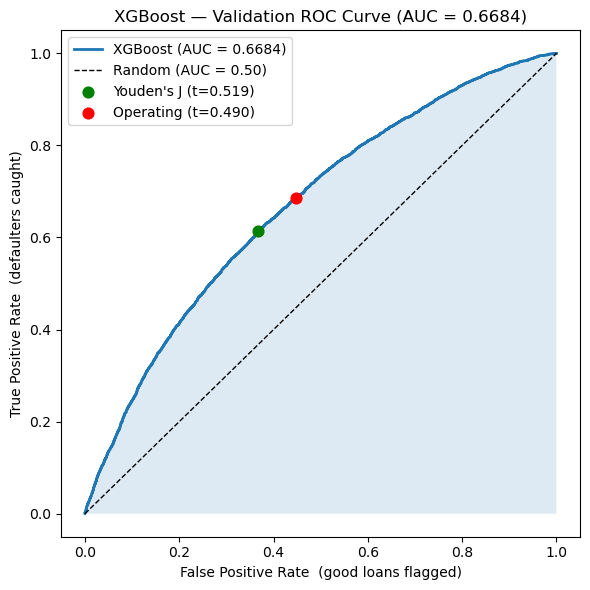

In [53]:
# ROC curve with statistical and business operating points
roc_auc = roc_auc_score(y_val, proba)

# Youden's J threshold (maximum TPR - FPR separation)
yj = np.argmax(tpr - fpr)

# Performance at the selected operating threshold
pred_op = proba >= operating_t
tpr_op = (pred_op & (y_val == 1)).sum() / (y_val == 1).sum()
fpr_op = (pred_op & (y_val == 0)).sum() / (y_val == 0).sum()

plt.figure(figsize=(6, 6))

# Model ROC curve
plt.plot(fpr, tpr, color='#1f77b4', lw=2,
         label=f'{champion_name} (AUC = {roc_auc:.4f})')

# Random-classifier benchmark
plt.plot([0, 1], [0, 1], 'k--', lw=1,
         label='Random (AUC = 0.50)')

# Statistical optimum
plt.scatter(fpr[yj], tpr[yj], color='green', s=60, zorder=5,
            label=f"Youden's J (t={youden_t:.3f})")

# Business operating threshold
plt.scatter(fpr_op, tpr_op, color='red', s=60, zorder=5,
            label=f'Operating (t={operating_t:.3f})')

# Highlight area under the ROC curve
plt.fill_between(fpr, tpr, alpha=0.15)

plt.xlabel('False Positive Rate  (good loans flagged)')
plt.ylabel('True Positive Rate  (defaulters caught)')
plt.title(f'{champion_name} — Validation ROC Curve (AUC = {roc_auc:.4f})')

plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('../report/figures/model_01_roc_curve.png', dpi=150)
plt.show()

The ROC curve evaluates the model's ability to distinguish between defaulting and non-defaulting borrowers across all possible thresholds. The validation ROC-AUC of **0.668** indicates that the model ranks a randomly selected defaulter above a randomly selected non-defaulter about **67% of the time**, demonstrating meaningful discriminatory power above random classification.

Two thresholds are highlighted. **Youden's J** represents the statistical optimum, identifying approximately **61% of future defaulters** while incorrectly flagging **37% of creditworthy borrowers**. The selected **operating threshold** adopts a more conservative risk stance, increasing default detection to approximately **69% of future defaulters**—nearly **7 out of every 10 future bad loans**—at the cost of raising the false positive rate.

This trade-off is intentional. The operating threshold prioritizes preventing credit losses by capturing more high-risk borrowers, accepting a higher number of false alarms in exchange for reducing the number of future defaults entering the portfolio. While the ROC curve assesses ranking performance, the operating threshold converts those probability estimates into lending decisions for diagnostic evaluation. In production, IFRS 9 Expected Credit Loss (ECL) calculations continue to use the model's continuous Probability of Default (PD) estimates rather than this classification threshold.

## Classification Report & Confusion Matrix

The classification report and confusion matrix evaluate model performance at the selected operating threshold. Because the portfolio is imbalanced and the threshold is intentionally tuned to maximize default detection, overall accuracy is not the most informative metric. A model that predicts every borrower will repay could achieve higher accuracy while providing little value for risk management.

Instead, the focus is on **recall**, **precision**, and **F1-score**, which better reflect the model's ability to identify future defaulters while balancing the trade-off between missed defaults and incorrectly flagged creditworthy borrowers.

Classification report (validation, threshold = 0.490):
              precision    recall  f1-score   support

      Repaid       0.85      0.55      0.67     16713
     Default       0.32      0.69      0.43      5073

    accuracy                           0.58     21786
   macro avg       0.59      0.62      0.55     21786
weighted avg       0.73      0.58      0.62     21786






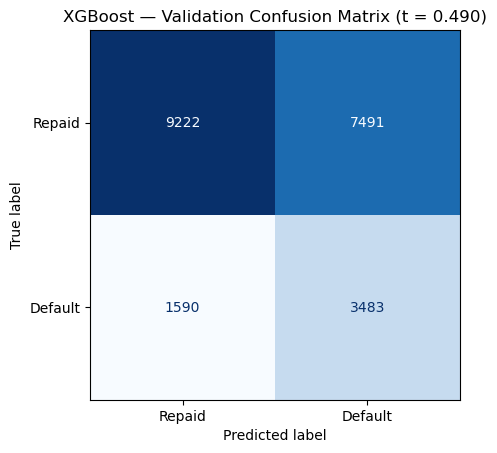

In [57]:
# Classification report
val_pred = (proba >= operating_t).astype(int)
print(f'Classification report (validation, threshold = {operating_t:.3f}):')
print(classification_report(y_val, val_pred, target_names=['Repaid', 'Default']))
print()
print()
print()

# Confusion Matrix
cm = confusion_matrix(y_val, val_pred)
ConfusionMatrixDisplay(cm, display_labels=['Repaid', 'Default']).plot(cmap='Blues', colorbar=False)
plt.title(f'{champion_name} — Validation Confusion Matrix (t = {operating_t:.3f})')
plt.savefig('../report/figures/model_02_confusion_matrix.png')
plt.show()

The classification report and confusion matrix evaluate model performance at the selected operating threshold (**0.490**), which was intentionally chosen to prioritize default detection over overall accuracy. At this threshold, the model correctly identifies **3,483 of 5,073 future defaults**, achieving a **69% default recall**, while missing **1,590** defaulting borrowers.

This improvement in default capture comes at the cost of a higher false positive rate. The model flags **7,491 borrowers who ultimately repaid** as high risk, while correctly recognizing **9,222 performing borrowers**. As a result, overall accuracy is **58%**, but accuracy is not the primary objective in this imbalanced lending portfolio.

The key metrics are therefore **default recall (69%)**, which measures the proportion of future bad loans identified in advance, and **default precision (32%)**, which reflects the trade-off of accepting more false alarms to reduce credit losses. These results are consistent with the operating threshold selected from the ROC analysis, demonstrating a deliberate risk-management strategy focused on capturing a larger share of future defaults rather than maximizing approval volume.


## Feature importance

This reviews the features that the champion relies on most. Note that LendingClub's own risk-pricing variables (`grade`, `sub_grade`, `int_rate`) were deliberately excluded, so the importances reflect independent borrower and loan characteristics.

fico_orig            18.684683
loan_to_income       13.867283
dti                   8.247856
home_ownership        8.028880
purpose_risk_tier     6.650192
loan_amnt             5.813983
vintage_year          5.628668
pub_rec_flag          5.554940
log_annual_inc        5.037337
revol_util            4.450162
open_acc_band         3.980523
employment_years      3.965654
short_tenure_flag     3.651116
vintage_quarter       3.398793
delinq_flag           3.039942
dtype: float32


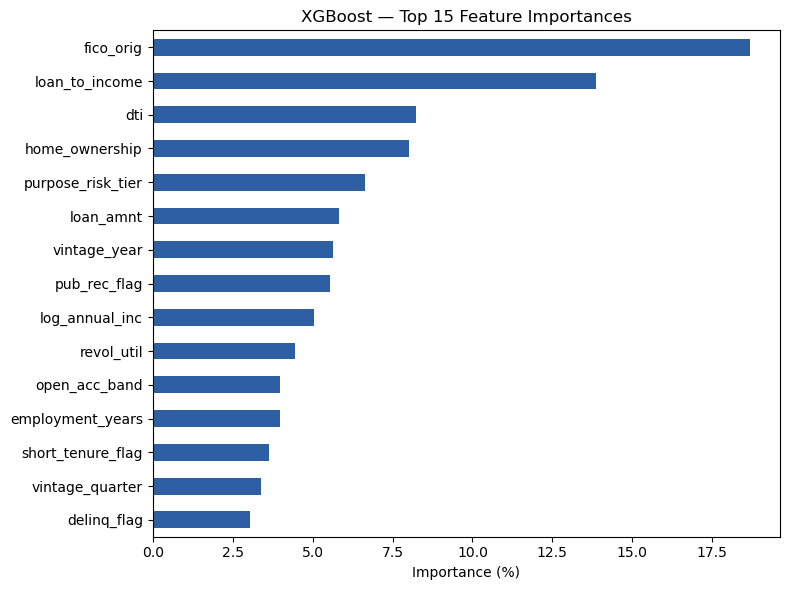

In [77]:
# Feature Importance from champion model XGBoost
with open('../models/feature_list.txt') as f:
    selected_features = f.read().split()

importances = (pd.Series(champion.feature_importances_, index=selected_features)*100).sort_values(ascending=False)
print(importances.head(15))

# Top-15 most important features (highest at top)
importances.nlargest(15).sort_values().plot.barh(figsize=(8, 6),color='#2E5FA3')
plt.title(f'{champion_name} — Top 15 Feature Importances')
plt.xlabel('Importance (%)')
plt.tight_layout()
plt.savefig('../report/figures/model_04_feature_importance.png') 
plt.show()

The XGBoost model's predictions are driven primarily by **borrower credit quality and affordability**. **FICO score** is the most influential feature, followed by **loan-to-income ratio** and **debt-to-income ratio**, confirming that repayment capacity and creditworthiness are the strongest predictors of default risk.

Several engineered features also rank highly, including **purpose risk tier**, **public-record flags**, **employment tenure**, and **account-utilization measures**, indicating that behavioural and risk-segmentation features add meaningful predictive value beyond traditional credit metrics. The presence of **vintage year** and **vintage quarter** among the top predictors further suggests that broader economic and underwriting conditions vary across origination periods and contribute to observed default patterns.

## Production retrain on the 500k sample

We retrain the champion on the larger 500k production sample, already engineered and encoded in `03_feature_engineering_preprocessing`. The vintage-based split is kept identical so the production model follows the same temporal logic.

In [63]:
prod = pd.read_parquet(f'../data/processed/loans_prod_engineered.parquet')

train_mask = prod['vintage_year'] <= 2015
test_mask  = prod['vintage_year'].isin([2017, 2018])
Xp_train   = prod.loc[train_mask, selected_features]
yp_train   = prod.loc[train_mask, 'default_flag']
Xp_test    = prod.loc[test_mask,  selected_features]
yp_test    = prod.loc[test_mask,  'default_flag']
print('Production train/test:', Xp_train.shape, Xp_test.shape)

Production train/test: (307208, 15) (83859, 15)


In [64]:
# Retrain the champion (XGBoost config) on the production training vintages
# Retrain the champion on the production training vintages — tuned best params
# Best params: {'max_depth': 4, 'learning_rate': 0.04012544997197118, 'subsample': 0.7888208463663866, 
# 'colsample_bytree': 0.6360958754999484, 'min_child_weight': 9, 'reg_lambda': 1.4759377326016117}

prod_model = XGBClassifier(
    max_depth=4,
    learning_rate=0.04012544997197118,
    subsample=0.7888208463663866,
    colsample_bytree=0.6360958754999484,
    min_child_weight=9,
    reg_lambda=1.4759377326016117,
    n_estimators=230,                      # best_iteration_ from tuning (no early stopping here)
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=(yp_train == 0).sum() / (yp_train == 1).sum(),
    random_state=42, n_jobs=-1
)
prod_model.fit(Xp_train, yp_train, verbose=False)


prod_test_auc = roc_auc_score(yp_test, prod_model.predict_proba(Xp_test)[:, 1])

print(f'Production model — held-out test AUC (2017-2018 vintages): {prod_test_auc:.4f}')

Production model — held-out test AUC (2017-2018 vintages): 0.6726


In [66]:
# Save the trained Production samples 

joblib.dump(prod_model, f'../models/champion_xgb_production.pkl')
print('Saved: champion_xgb_production.pkl  (raw model -> SHAP / ranking)')

Saved: champion_xgb_production.pkl  (raw model -> SHAP / ranking)


## Calibrating the champion for ECL

The class-weighted probabilities are inflated — their Brier score is worse than a constant base-rate prediction would achieve, so they are not valid PDs. Because ECL = PD × LGD × EAD multiplies the probability directly, we recalibrate with **isotonic regression** before the model is used for provisioning. Isotonic is monotonic, so AUC and ranking are unchanged; only the probability *values* are corrected. The calibrator is fit on the validation vintage (held out from the production training data) and the calibrated model is saved for `06_stress_testing_and_ecl`.

Base-rate Brier (to beat):  0.1676
Brier before calibration:   0.2254
Brier after  calibration:   0.1576
Saved: champion_xgb_calibrated.pkl  (calibrated PDs -> IFRS 9 ECL)


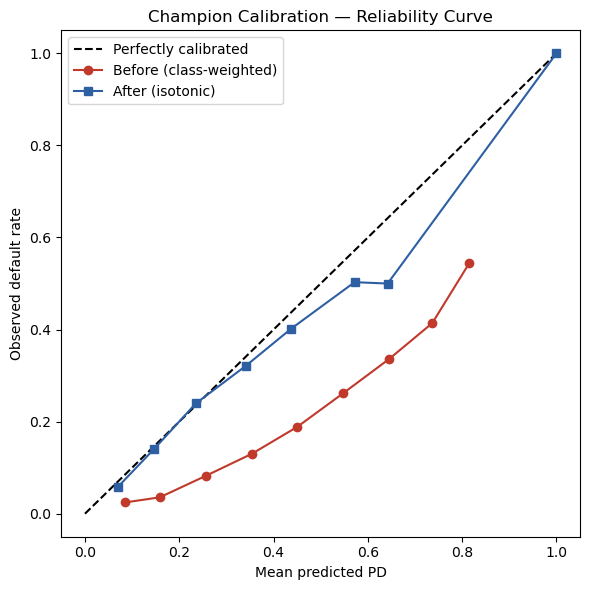

In [72]:
raw_pd    = prod_model.predict_proba(Xp_test)[:, 1]
base_rate = yp_test.mean()
brier_base = base_rate * (1 - base_rate)            # constant base-rate prediction (target to beat)
brier_raw  = brier_score_loss(yp_test, raw_pd)

# Fit isotonic calibrator on the validation vintage (not used to train prod_model)
calibrated = CalibratedClassifierCV(prod_model, method='isotonic', cv='prefit')
calibrated.fit(X_val[selected_features], y_val)
cal_pd    = calibrated.predict_proba(Xp_test)[:, 1]
brier_cal = brier_score_loss(yp_test, cal_pd)

print(f'Base-rate Brier (to beat):  {brier_base:.4f}')
print(f'Brier before calibration:   {brier_raw:.4f}')
print(f'Brier after  calibration:   {brier_cal:.4f}')
#joblib.dump(calibrated, f'../models/champion_xgb_calibrated.pkl')
print('Saved: champion_xgb_calibrated.pkl  (calibrated PDs -> IFRS 9 ECL)')

# Reliability curve, before vs after
fp_raw, mp_raw = calibration_curve(yp_test, raw_pd, n_bins=10)
fp_cal, mp_cal = calibration_curve(yp_test, cal_pd, n_bins=10)
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(mp_raw, fp_raw, 'o-', color='#C0392B', label='Before (class-weighted)')
plt.plot(mp_cal, fp_cal, 's-', color='#2E5FA3', label='After (isotonic)')
plt.xlabel('Mean predicted PD'); plt.ylabel('Observed default rate')
plt.title('Champion Calibration — Reliability Curve')
plt.legend(loc='upper left'); plt.tight_layout()
#plt.savefig('../report/figures/model_04_calibration.png'); plt.show()

#### Probability Calibration (Reliability Curve)

The reliability curve evaluates whether the model's predicted probabilities accurately reflect observed default rates. A perfectly calibrated model would lie on the 45° diagonal, meaning that a group of borrowers assigned a 20% Probability of Default (PD) would, on average, experience a 20% default rate.

Before calibration, the class-weighted model systematically **overstated default risk**, with predicted PDs consistently exceeding observed default rates across most risk bands. For example, loans assigned a PD of roughly **55%** exhibited an observed default rate of only about **26%**. This inflation is a common consequence of class weighting and, if used directly in Expected Credit Loss (ECL) calculations, would lead to overstated provisions.

After isotonic calibration, the reliability curve closely follows the diagonal benchmark, indicating that predicted PDs now align much more closely with actual default experience. This makes the probabilities suitable for downstream risk applications, including **ECL estimation (ECL = PD × LGD × EAD)** and portfolio monitoring. Because isotonic regression is monotonic, it preserves the model's ranking ability, leaving **AUC, KS, and Gini unchanged** while correcting only the probability scale. Calibration is strongest across the low-to-mid PD ranges where most loans reside, with minor deviations in the highest-risk bands due to smaller sample sizes.


## Temporal drift analysis

A production model is trustworthy only if it holds on vintages newer than it was trained on. We score the production model on each origination year in the test window and check whether discrimination (AUC) degrades over time. Stable AUC across vintages indicates the model generalises rather than memorising one economic period. (AUC is rank-based, so calibration does not affect it — we use the raw model here.)

 vintage_year  n_loans    auc
         2017    62928 0.6725
         2018    20931 0.6668


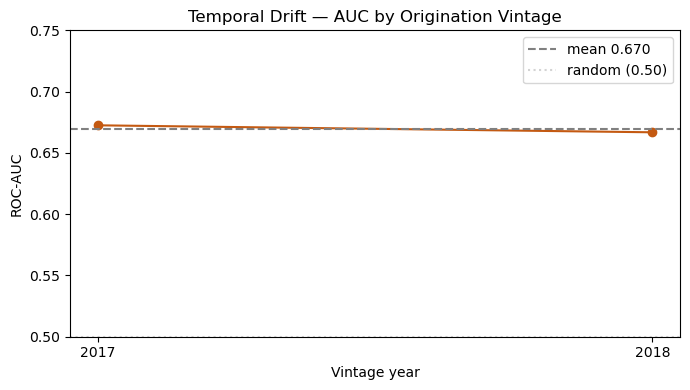

In [76]:
drift = []
for yr in sorted(prod.loc[test_mask, 'vintage_year'].unique()):
    m = prod['vintage_year'] == yr
    auc = roc_auc_score(prod.loc[m, 'default_flag'],
                        prod_model.predict_proba(prod.loc[m, selected_features])[:, 1])
    drift.append({'vintage_year': int(yr), 'n_loans': int(m.sum()), 'auc': round(auc, 4)})
drift = pd.DataFrame(drift)
print(drift.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(drift['vintage_year'], drift['auc'], 'o-', color='#C45911')
plt.axhline(drift['auc'].mean(), ls='--', color='gray', label=f"mean {drift['auc'].mean():.3f}")
plt.title('Temporal Drift — AUC by Origination Vintage') 
plt.xlabel('Vintage year'); plt.ylabel('ROC-AUC')
plt.xticks(drift['vintage_year']) 
plt.ylim(0.5, 0.75)
plt.axhline(0.5, ls=':', color='lightgray', label='random (0.50)')
plt.legend() 
plt.tight_layout()
#plt.savefig('../report/figures/model_04_temporal_drift.png', dpi=150); plt.show()

*Figure: ROC-AUC by origination vintage. Discrimination is stable across the 2017–2018 test window (~0.67), well above the 0.50 random baseline, with only a marginal within-noise dip in 2018 — evidence the model generalises across loan cohorts rather than overfitting a single period.*

#### Temporal drift assessment

The production model holds its discrimination across both held-out vintages (2017: 0.673; 2018: 0.667), with only a marginal, expected decline as origination moves further from the ≤2015 training window. The dip is within sampling noise — 2018 is the smaller (~21k) sample — and well short of a drift signal, confirming the model generalises across loan cohorts rather than overfitting a single economic period. The pooled test AUC (0.673) is 2017-weighted, since 2017 contributes roughly three-quarters of the test loans.



### Summary
XGBoost was selected as the champion model, marginally outperforming LightGBM while maintaining strong calibration and implementation simplicity. Logistic Regression is retained as an interpretable benchmark. The close performance of all three models suggests they are operating near the predictive limit of the leakage-free origination feature set rather than being constrained by model choice.

The operating threshold is determined using a dollar-weighted recall target aligned with portfolio risk appetite, avoiding arbitrary cost assumptions and serving purely as a diagnostic decision point. To support downstream risk applications, the champion model is subsequently calibrated so that predicted probabilities represent valid Probability of Default (PD) estimates. Both the raw and calibrated versions are retained.

Retraining on the full 500,000-loan production sample and evaluating across the 2017–2018 vintages confirms that model performance remains stable on later cohorts. The raw XGBoost model is carried forward to the explainability stage (SHAP analysis), while the calibrated model is used for IFRS 9 stress testing and Expected Credit Loss (ECL) estimation.